# Main Clustering Pipeline
- Walks through the main pipeline (clustering → create signs)
- Now including: music audio captions for the "music" label via log-odds analysis

## Imports

In [1]:
import os
import re
import gc
import json
import glob
import tqdm
import pickle
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import torch
import clip
import umap
import hdbscan
from sklearn.metrics.pairwise import cosine_distances
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

---
## Functions

### Step 1: Embedding Generation

In [2]:
def processImageCaptionEmbeddings(image_dir, text_dir, model_name="ViT-B/32",
                                   device=None, batch_size=32):
    """
    process images and captions, create fused embeddings via element-wise addition.
    """
    # setup device (prefer mps for mac, then cuda, then cpu)
    if device is None:
        device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
    
    # load clip model
    model, preprocess = clip.load(model_name, device=device)
    
    # find all image files and store by stem name for matching
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}
    image_files = {}
    for ext in image_extensions:
        for img_path in Path(image_dir).glob(f"*{ext}"):
            image_files[img_path.stem] = img_path
        for img_path in Path(image_dir).glob(f"*{ext.upper()}"):
            image_files[img_path.stem] = img_path
    
    # find caption files and match with corresponding images
    matched_pairs = []
    for txt_path in Path(text_dir).glob("CAPTION_*"):
        # extract frame name by removing "CAPTION_" prefix
        frame_name = txt_path.stem.replace("CAPTION_", "", 1)
        
        if frame_name in image_files:
            matched_pairs.append({
                'frame_name': frame_name,
                'image_path': str(image_files[frame_name]),
                'text_path': str(txt_path)
            })
    
    if not matched_pairs:
        raise ValueError("no matched image-caption pairs found")
    
    print(f"found {len(matched_pairs)} matched image-caption pairs")
    
    # sort pairs by frame name for deterministic ordering
    matched_pairs = sorted(matched_pairs, key=lambda x: x['frame_name'])
    
    all_embeddings = []
    all_metadata = []
    
    # process in batches to manage memory
    for i in tqdm.tqdm(range(0, len(matched_pairs), batch_size), desc="processing batches", leave=False):
        batch = matched_pairs[i:i + batch_size]
        
        images = []
        texts = []
        
        for pair in batch:
            # load and preprocess image
            img = Image.open(pair['image_path']).convert('RGB')
            images.append(preprocess(img))
            
            # load caption text
            with open(pair['text_path'], 'r', encoding='utf-8') as f:
                caption_text = f.read().strip()
            texts.append(caption_text)
        
        # create batched tensors
        image_batch = torch.stack(images).to(device)
        text_tokens = clip.tokenize(texts, truncate=True).to(device)
        
        # generate embeddings
        with torch.no_grad():
            image_embeddings = model.encode_image(image_batch)
            text_embeddings = model.encode_text(text_tokens)
            
            # normalize embeddings to unit length
            image_embeddings = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)
            text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)
            
            # fuse via element-wise addition (per multimodal clustering literature)
            fused_embeddings = image_embeddings + text_embeddings
            
            fused_embeddings_np = fused_embeddings.cpu().numpy()
            all_embeddings.append(fused_embeddings_np)
        
        # store metadata for traceability
        for pair in batch:
            all_metadata.append({
                'frame_name': pair['frame_name'],
                'image_path': pair['image_path'],
                'text_path': pair['text_path']
            })
        
        # memory cleanup
        del images, image_batch, text_tokens, image_embeddings, text_embeddings, fused_embeddings
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()
    
    # concatenate all batch embeddings
    embeddings = np.vstack(all_embeddings)
    
    # cleanup model from memory
    del model, all_embeddings
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    
    return embeddings, all_metadata


### Step 2: Dimensionality Reduction and Clustering

In [3]:
def performClusteringPipeline(embeddings, metadata, n_neighbors=15, min_dist=0.1,
                               n_components=5, min_cluster_size=5, min_samples=3):
    """
    perform umap dimensionality reduction followed by hdbscan clustering.
    """
    # configure umap for dimensionality reduction
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric='cosine',
        random_state=42  # for reproducibility
    )

    # reduce high-dimensional clip embeddings to lower dimensional space
    umap_embeddings = reducer.fit_transform(embeddings)
    
    # free memory from original embeddings
    del embeddings
    gc.collect()

    # configure hdbscan for density-based clustering
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric='euclidean',
        cluster_selection_method='eom'  # excess of mass for cluster selection
    )

    # fit clusterer and get cluster labels (-1 indicates noise)
    labels = clusterer.fit_predict(umap_embeddings)
    
    return umap_embeddings, clusterer, labels


### Step 3: Select Representative Images from Each Cluster

In [4]:
def selectRepresentativeImages(clusterer, labels, metadata, n_representatives=8):
    """
    select representative images from each cluster using hdbscan stability scores.
    higher probability scores indicate more stable/typical cluster members.
    """
    cluster_representatives = {}
    
    # get unique cluster labels, excluding noise (-1)
    unique_clusters = sorted([label for label in set(labels) if label != -1])
    
    for cluster_id in unique_clusters:
        # get indices of points in this cluster
        cluster_indices = np.where(labels == cluster_id)[0]
        
        # get stability scores for points in this cluster
        # higher values = more stable/typical of the cluster
        if hasattr(clusterer, 'probabilities_'):
            stabilities = clusterer.probabilities_[cluster_indices]
        else:
            # fallback: use inverted outlier scores
            stabilities = 1 - clusterer.outlier_scores_[cluster_indices]
        
        # select top n_representatives by stability score
        n_to_select = min(n_representatives, len(cluster_indices))
        top_indices = np.argsort(stabilities)[-n_to_select:][::-1]
        
        representative_indices = cluster_indices[top_indices].tolist()
        cluster_representatives[cluster_id] = representative_indices
    
    gc.collect()
    
    return cluster_representatives


### Step 4: Submodular Optimization for Diversity

In [5]:
def selectDiverseImages(embeddings, candidate_indices, n_select=8):
    """
    use greedy submodular optimization to select diverse images.
    maximizes diversity while maintaining representativeness by iteratively
    selecting the point farthest from already selected points.
    """
    if len(candidate_indices) <= n_select:
        return candidate_indices
    
    # get embeddings for candidate points
    candidate_embeddings = embeddings[candidate_indices]
    
    # initialize with the most central point (closest to centroid)
    center = candidate_embeddings.mean(axis=0)
    distances_to_center = cosine_distances(candidate_embeddings, center.reshape(1, -1)).flatten()
    selected = [np.argmin(distances_to_center)]
    selected_indices = [candidate_indices[selected[0]]]
    
    # greedy selection: iteratively add point that maximizes minimum distance to selected set
    while len(selected) < n_select:
        selected_embeddings = candidate_embeddings[selected]
        
        # compute minimum distance to selected set for each candidate
        min_distances = []
        for i, emb in enumerate(candidate_embeddings):
            if i in selected:
                min_distances.append(-1)  # already selected, skip
            else:
                distances = cosine_distances(emb.reshape(1, -1), selected_embeddings).flatten()
                min_distances.append(distances.min())
        
        # select point with maximum minimum distance (farthest from selected set)
        next_idx = np.argmax(min_distances)
        selected.append(next_idx)
        selected_indices.append(candidate_indices[next_idx])
    
    del candidate_embeddings, selected_embeddings
    gc.collect()
    
    return selected_indices


def optimizeClusterRepresentatives(embeddings, cluster_representatives, n_final=8):
    """
    apply submodular optimization to each cluster's representatives
    to ensure diversity in the final selection.
    """
    optimized_representatives = {}

    # optimize each cluster's representatives for diversity
    for cluster_id, candidate_indices in cluster_representatives.items():
        diverse_indices = selectDiverseImages(embeddings, candidate_indices, n_select=n_final)
        optimized_representatives[cluster_id] = diverse_indices
    
    gc.collect()
    
    return optimized_representatives


### Step 5: Create Cluster Composite Images

In [6]:
def createClusterComposite(image_paths, grid_size=(3, 3), image_size=300):
    """
    arrange multiple images into a single composite grid.
    """
    n_images = len(image_paths)
    rows, cols = grid_size
    
    # expand grid if needed to fit all images
    while rows * cols < n_images:
        if rows <= cols:
            rows += 1
        else:
            cols += 1
    
    # create blank white canvas
    composite_width = cols * image_size
    composite_height = rows * image_size
    composite = Image.new('RGB', (composite_width, composite_height), color='white')
    
    # paste each image into the grid
    for idx, img_path in enumerate(image_paths):
        if idx >= rows * cols:
            break
            
        row = idx // cols
        col = idx % cols
        
        # load, resize, and paste image
        img = Image.open(img_path).convert('RGB')
        img = img.resize((image_size, image_size), Image.Resampling.LANCZOS)
        
        x = col * image_size
        y = row * image_size
        composite.paste(img, (x, y))
    
    return composite


### Step 6: c-TF-IDF for Keyword Extraction

In [7]:
def extractTextsByVideo(metadata, text_dir, text_types=['CAPTION', 'COMMENTS', 'AUDIO']):
    """
    extract and organize texts by video (frame group).
    groups all text files associated with frames from the same video.
    """
    video_texts = defaultdict(list)
    frame_to_video = {}
    
    text_dir = Path(text_dir)
    
    for meta in metadata:
        frame_name = meta['frame_name']
        
        # extract video name from frame name (assumes format like "video_name_001")
        parts = frame_name.rsplit('_', 1)
        if len(parts) == 2 and parts[1].isdigit():
            video_name = parts[0]
        else:
            video_name = frame_name
        
        frame_to_video[frame_name] = video_name
        
        # collect texts from different sources (captions, comments, audio transcripts)
        texts = []
        for text_type in text_types:
            text_file = text_dir / f"{text_type}_{frame_name}.txt"
            if text_file.exists():
                with open(text_file, 'r', encoding='utf-8') as f:
                    text_content = f.read().strip()
                    if text_content:
                        texts.append(text_content)
        
        if texts:
            video_texts[video_name].extend(texts)
    
    # combine all texts for each video into single string
    video_combined_texts = {video: ' '.join(texts) for video, texts in video_texts.items()}
    
    return video_combined_texts, frame_to_video


def performCTFIDF(documents_per_cluster, n_top_words=10):
    """
    perform class-based tf-idf (c-tf-idf) to extract distinctive keywords per cluster.
    c-tf-idf identifies words that are frequent in a cluster but rare across other clusters.
    """
    cluster_ids = sorted(documents_per_cluster.keys())
    documents = [documents_per_cluster[cid] for cid in cluster_ids]
    
    # create document-term matrix using word counts
    vectorizer = CountVectorizer(
        max_features=1000,
        stop_words='english',
        ngram_range=(1, 2),  # include unigrams and bigrams
        min_df=1
    )
    
    try:
        word_counts = vectorizer.fit_transform(documents)
        words = vectorizer.get_feature_names_out()
    except ValueError as e:
        print(f"warning: could not extract keywords - {e}")
        return {cid: [] for cid in cluster_ids}
    
    n_clusters = len(cluster_ids)
    cluster_keywords = {}
    
    for idx, cluster_id in enumerate(cluster_ids):
        # get term frequencies for this cluster
        tf = np.asarray(word_counts[idx].todense()).flatten()
        
        # calculate document frequency (how many clusters contain each term)
        df = (word_counts > 0).sum(axis=0)
        df = np.asarray(df).flatten()
        
        # calculate inverse document frequency
        idf = np.log(n_clusters / (df + 1))
        
        # c-tf-idf score: term frequency weighted by inverse document frequency
        c_tf_idf = tf * idf
        
        # extract top keywords by c-tf-idf score
        top_indices = np.argsort(c_tf_idf)[-n_top_words:][::-1]
        top_keywords = [words[i] for i in top_indices if c_tf_idf[i] > 0]
        
        cluster_keywords[cluster_id] = top_keywords
    
    del word_counts, vectorizer
    gc.collect()
    
    return cluster_keywords


def extractClusterKeywords(labels, metadata, text_dir, n_top_words=10):
    """
    extract distinctive keywords for each cluster using c-tf-idf.
    """
    # get texts organized by video
    video_texts, frame_to_video = extractTextsByVideo(metadata, text_dir)
    
    # group texts by cluster label
    documents_per_cluster = defaultdict(list)
    
    for idx, label in enumerate(labels):
        if label == -1:  # skip noise points
            continue
        
        frame_name = metadata[idx]['frame_name']
        video_name = frame_to_video.get(frame_name)
        
        if video_name and video_name in video_texts:
            documents_per_cluster[label].append(video_texts[video_name])
    
    # combine texts for each cluster, removing duplicates
    cluster_documents = {}
    for cluster_id, texts in documents_per_cluster.items():
        unique_texts = []
        seen = set()
        for text in texts:
            if text not in seen:
                unique_texts.append(text)
                seen.add(text)
        cluster_documents[cluster_id] = ' '.join(unique_texts)
    
    # perform c-tf-idf to get distinctive keywords
    cluster_keywords = performCTFIDF(cluster_documents, n_top_words=n_top_words)
    
    del video_texts, documents_per_cluster, cluster_documents
    gc.collect()
    
    return cluster_keywords


### Step 6.5: Extract Comment Keywords Using Log Odds Ratios

In [8]:
def extractClusterComments(labels, metadata, comments_dict, n_top_words=8, min_word_length=3):
    """
    extract distinctive comment keywords for each cluster using log odds ratios.
    log odds ratio compares the probability of a word appearing in a cluster
    versus all other clusters, highlighting cluster-specific vocabulary.
    """
    # group comments by cluster
    cluster_comments_raw = defaultdict(list)
    
    for idx, label in enumerate(labels):
        if label == -1:  # skip noise points
            continue
        
        # try to find comments using different identifier formats
        frame_identifier = metadata[idx].get('image_path') or metadata[idx].get('frame_name')
        frame_name = metadata[idx].get('frame_name')
        
        comments = comments_dict.get(frame_identifier, comments_dict.get(frame_name, []))
        
        if comments:
            cluster_comments_raw[label].extend(comments)
    
    # tokenize and count words for each cluster
    cluster_word_counts = {}
    cluster_total_words = {}
    all_words_counter = Counter()
    total_words_all = 0
    
    for cluster_id, comments in cluster_comments_raw.items():
        combined_text = ' '.join(comments).lower()
        
        # simple tokenization: extract alphabetic words
        words = re.findall(r'\b[a-z]+\b', combined_text)
        words = [w for w in words if len(w) >= min_word_length]
        
        word_counter = Counter(words)
        cluster_word_counts[cluster_id] = word_counter
        cluster_total_words[cluster_id] = sum(word_counter.values())
        
        # track global word counts across all clusters
        all_words_counter.update(words)
        total_words_all += len(words)
    
    # handle case where no comments exist
    if not cluster_word_counts:
        return {label: "no comments" for label in set(labels) if label != -1}
    
    # calculate log odds ratios for each cluster
    cluster_comments = {}
    unique_clusters = sorted([label for label in set(labels) if label != -1])
    
    for cluster_id in unique_clusters:
        if cluster_id not in cluster_word_counts:
            cluster_comments[cluster_id] = "no comments"
            continue
        
        cluster_words = cluster_word_counts[cluster_id]
        cluster_total = cluster_total_words[cluster_id]
        
        if cluster_total == 0:
            cluster_comments[cluster_id] = "no comments"
            continue
        
        # calculate word counts for all other clusters combined
        other_words_counter = Counter()
        other_total = 0
        
        for other_id, other_word_counts in cluster_word_counts.items():
            if other_id != cluster_id:
                other_words_counter.update(other_word_counts)
                other_total += cluster_total_words[other_id]
        
        if other_total == 0:
            # only one cluster has comments, return most frequent words
            top_words = [word for word, _ in cluster_words.most_common(n_top_words)]
            cluster_comments[cluster_id] = ', '.join(top_words)
            continue
        
        # calculate log odds ratio for each word
        log_odds_scores = {}
        
        for word in cluster_words:
            # add-1 smoothing to avoid division by zero
            p_word_in_cluster = (cluster_words[word] + 1) / (cluster_total + len(cluster_words))
            p_word_in_others = (other_words_counter[word] + 1) / (other_total + len(other_words_counter))
            
            # log odds ratio: positive = more likely in this cluster
            log_odds = np.log(p_word_in_cluster / p_word_in_others)
            log_odds_scores[word] = log_odds
        
        # select top words by log odds ratio
        top_words = sorted(log_odds_scores.items(), key=lambda x: x[1], reverse=True)[:n_top_words]
        top_words_str = ', '.join([word for word, score in top_words])
        
        cluster_comments[cluster_id] = top_words_str if top_words_str else "no distinctive comments"
    
    # ensure all clusters have an entry
    for cluster_id in unique_clusters:
        if cluster_id not in cluster_comments:
            cluster_comments[cluster_id] = "no comments"
    
    del cluster_comments_raw, cluster_word_counts, all_words_counter
    gc.collect()
    
    return cluster_comments

### Step 7: Extract Music Descriptions via Log-Odds Ratios
Replaces the previous genre extraction with log-odds analysis on music captions.

In [9]:
def extractVideoNameFromFrame(frame_name):
    """
    extract the base video name from a frame filename.
    handles format like "videoname_cluster0_frame001"
    """
    pattern = r'^(.+)_cluster\d+_frame\d+$'
    match = re.match(pattern, frame_name)
    return match.group(1) if match else frame_name


def loadMusicCaptions(music_captions_dir):
    """
    load music captions from directory.
    expects files named "MUSIC_CAPTION_videoname.txt"
    """
    music_captions = {}
    music_dir = Path(music_captions_dir)
    
    if not music_dir.exists():
        return music_captions
    
    for caption_file in music_dir.glob("MUSIC_CAPTION_*.txt"):
        # extract video name from filename
        video_name = caption_file.stem.replace("MUSIC_CAPTION_", "")
        
        with open(caption_file, 'r', encoding='utf-8') as f:
            caption = f.read().strip()
        
        if caption:
            music_captions[video_name] = caption
    
    print(f"loaded {len(music_captions)} music captions from {music_captions_dir}")
    return music_captions


def extractClusterMusicDescriptions(labels, metadata, music_captions_dict, n_top_words=8, min_word_length=3):
    """
    extract distinctive music description keywords for each cluster using log odds ratios.
    identifies music-related vocabulary that distinguishes each cluster.
    """
    # map clusters to their associated videos
    cluster_videos = defaultdict(set)
    
    for idx, label in enumerate(labels):
        if label == -1:
            continue
        frame_name = metadata[idx]['frame_name']
        video_name = extractVideoNameFromFrame(frame_name)
        cluster_videos[label].add(video_name)
    
    # collect music captions for each cluster
    cluster_texts = defaultdict(list)
    
    for cluster_id, videos in cluster_videos.items():
        for video_name in videos:
            if video_name in music_captions_dict:
                cluster_texts[cluster_id].append(music_captions_dict[video_name])
    
    # tokenize and count words for each cluster
    cluster_word_counts = {}
    cluster_total_words = {}
    all_words_counter = Counter()
    
    for cluster_id, texts in cluster_texts.items():
        combined_text = ' '.join(texts).lower()
        words = re.findall(r'\b[a-z]+\b', combined_text)
        words = [w for w in words if len(w) >= min_word_length]
        
        word_counter = Counter(words)
        cluster_word_counts[cluster_id] = word_counter
        cluster_total_words[cluster_id] = sum(word_counter.values())
        
        all_words_counter.update(words)
    
    # calculate log odds ratios for each cluster
    cluster_music_descriptions = {}
    unique_clusters = sorted([label for label in set(labels) if label != -1])
    
    for cluster_id in unique_clusters:
        if cluster_id not in cluster_word_counts:
            cluster_music_descriptions[cluster_id] = "unknown"
            continue
        
        cluster_words = cluster_word_counts[cluster_id]
        cluster_total = cluster_total_words[cluster_id]
        
        if cluster_total == 0:
            cluster_music_descriptions[cluster_id] = "unknown"
            continue
        
        # calculate word counts for all other clusters
        other_words_counter = Counter()
        other_total = 0
        
        for other_id, other_word_counts in cluster_word_counts.items():
            if other_id != cluster_id:
                other_words_counter.update(other_word_counts)
                other_total += cluster_total_words[other_id]
        
        if other_total == 0:
            # only one cluster has music captions
            top_words = [word for word, _ in cluster_words.most_common(n_top_words)]
            cluster_music_descriptions[cluster_id] = ', '.join(top_words)
            continue
        
        # calculate log odds ratio for each word
        log_odds_scores = {}
        
        for word in cluster_words:
            # add-1 smoothing
            p_word_in_cluster = (cluster_words[word] + 1) / (cluster_total + len(cluster_words))
            p_word_in_others = (other_words_counter[word] + 1) / (other_total + len(other_words_counter))
            
            log_odds = np.log(p_word_in_cluster / p_word_in_others)
            log_odds_scores[word] = log_odds
        
        # select top words by log odds ratio
        top_words = sorted(log_odds_scores.items(), key=lambda x: x[1], reverse=True)[:n_top_words]
        top_words_str = ', '.join([word for word, score in top_words])
        
        cluster_music_descriptions[cluster_id] = top_words_str if top_words_str else "unknown"
    
    # ensure all clusters have an entry
    for cluster_id in unique_clusters:
        if cluster_id not in cluster_music_descriptions:
            cluster_music_descriptions[cluster_id] = "unknown"
    
    del cluster_videos, cluster_texts, cluster_word_counts, all_words_counter
    gc.collect()
    
    return cluster_music_descriptions

### Step 8: Create Final Visualization Grid

In [10]:

def createVisualizationGrid(cluster_representatives, metadata, cluster_keywords,
                            cluster_genres, cluster_comments, labels, output_path,
                            n_columns=3, composite_size=300, title_fontsize=10,
                            max_clusters_display=30, max_text_length=60):
    """
    create final visualization grid with cluster composites and labels.
    each cell shows a 3x3 grid of representative images with cluster metadata.
    """
    cluster_ids = sorted(cluster_representatives.keys())
    
    # limit to largest clusters if needed
    if max_clusters_display is not None and len(cluster_ids) > max_clusters_display:
        cluster_sizes = {cid: np.sum(labels == cid) for cid in cluster_ids}
        selected_clusters = sorted(cluster_sizes.items(), 
                                  key=lambda x: x[1], 
                                  reverse=True)[:max_clusters_display]
        cluster_ids = [cid for cid, size in selected_clusters]
    
    n_clusters = len(cluster_ids)
    n_rows = (n_clusters + n_columns - 1) // n_columns
    
    # setup figure dimensions
    fig_width = n_columns * 6
    fig_height = n_rows * 8
    
    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=False)
    
    gs = gridspec.GridSpec(n_rows, n_columns, figure=fig, 
                          hspace=0.6, wspace=0.3,
                          top=0.95, bottom=0.05, left=0.05, right=0.95)
    
    # create subplot for each cluster
    for idx, cluster_id in enumerate(cluster_ids):
        row = idx // n_columns
        col = idx % n_columns
        
        ax = fig.add_subplot(gs[row, col])
        
        # get representative images for this cluster
        representative_indices = cluster_representatives[cluster_id]
        image_paths = [metadata[i]['image_path'] for i in representative_indices]
        
        # create composite image grid
        composite = createClusterComposite(image_paths, grid_size=(3, 3), 
                                          image_size=composite_size)
        
        ax.imshow(composite)
        ax.axis('off')
        
        # helper to truncate long text
        def truncate_text(text, max_length):
            if len(text) > max_length:
                return text[:max_length-3] + '...'
            return text
        
        # format cluster metadata for title
        keywords = cluster_keywords.get(cluster_id, [])
        keywords_str = ', '.join(keywords[:5]) if keywords else 'no keywords'
        keywords_str = truncate_text(keywords_str, max_text_length)
        
        comments_str = cluster_comments.get(cluster_id, 'no comments')
        comments_str = truncate_text(comments_str, max_text_length)
        
        genre = cluster_genres.get(cluster_id, 'unknown')
        genre = truncate_text(genre, max_text_length)
        
        # create multi-line title with cluster info
        title = (f"sign: {cluster_id}\n"
                f"text: {keywords_str}\n"
                f"interpretant: {comments_str}\n"
                f"genre: {genre}")
        
        ax.set_title(title, fontsize=title_fontsize, pad=15, 
                    ha='center', va='top',
                    multialignment='left',
                    linespacing=1.2)
    
    # hide empty subplots
    for idx in range(n_clusters, n_rows * n_columns):
        row = idx // n_columns
        col = idx % n_columns
        ax = fig.add_subplot(gs[row, col])
        ax.axis('off')
    
    # save figure
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    plt.savefig(output_path, dpi=450, bbox_inches='tight', 
               facecolor='white', edgecolor='none',
               pad_inches=0.3)
    
    print(f"visualization saved to: {output_path}")
    
    plt.close()
    
    del fig, composite
    gc.collect()

### Step 9: Save and Load Functions

In [11]:
def saveClusteringOutputs(save_dir, embeddings, metadata, umap_embeddings,
                          clusterer, labels, cluster_representatives):
    """
    save all clustering outputs to disk for later reuse.
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"\nsaving outputs to {save_dir}...")
    
    # save numpy arrays
    np.save(save_dir / 'embeddings.npy', embeddings)
    np.save(save_dir / 'umap_embeddings.npy', umap_embeddings)
    np.save(save_dir / 'labels.npy', labels)
    
    # save metadata as json
    with open(save_dir / 'metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)
    
    # save hdbscan clusterer model
    with open(save_dir / 'clusterer.pkl', 'wb') as f:
        pickle.dump(clusterer, f)
    
    # save cluster representatives (convert numpy types to native python for json)
    with open(save_dir / 'cluster_representatives.json', 'w') as f:
        serializable_reps = {int(k): [int(i) for i in v] 
                            for k, v in cluster_representatives.items()}
        json.dump(serializable_reps, f, indent=2)
    
    print("all outputs saved successfully!")
    
    gc.collect()


def loadClusteringOutputs(save_dir):
    """
    load previously saved clustering outputs.
    """
    save_dir = Path(save_dir)
    
    print(f"\nloading outputs from {save_dir}...")
    
    # load numpy arrays
    embeddings = np.load(save_dir / 'embeddings.npy')
    umap_embeddings = np.load(save_dir / 'umap_embeddings.npy')
    labels = np.load(save_dir / 'labels.npy')
    
    # load metadata
    with open(save_dir / 'metadata.json', 'r') as f:
        metadata = json.load(f)
    
    # load clusterer model
    with open(save_dir / 'clusterer.pkl', 'rb') as f:
        clusterer = pickle.load(f)
    
    # load cluster representatives and convert string keys back to integers
    with open(save_dir / 'cluster_representatives.json', 'r') as f:
        cluster_representatives = json.load(f)
        cluster_representatives = {int(k): v for k, v in cluster_representatives.items()}
    
    print("all outputs loaded successfully!")
    
    return embeddings, metadata, umap_embeddings, clusterer, labels, cluster_representatives



### Main Pipeline Function

In [12]:
def runCompleteClusteringPipeline(
    image_dir,
    text_dir,
    music_captions_dir,
    comments_dict=None,
    output_dir='clustering_output',
    output_viz_name='cluster_visualization.png',
    n_representatives=8,
    n_columns=3,
    max_clusters_display=30,
    skip_to_visualization=False,
    saved_outputs_dir=None,
    umap_n_neighbors=15,
    umap_min_dist=0.1,
    umap_n_components=5,
    hdbscan_min_cluster_size=5,
    hdbscan_min_samples=3,
    n_keywords=10,
    n_comment_keywords=8,
    n_music_keywords=8
):
    """
    complete pipeline for image clustering and visualization.
    
    steps:
    1. generate fused image-caption embeddings
    2. reduce dimensionality with umap and cluster with hdbscan
    3. select representative images using stability scores
    4. optimize representatives for diversity
    5. save intermediate outputs
    6. extract keywords via c-tf-idf
    7. extract comment keywords via log odds ratios
    8. extract music description keywords via log odds ratios
    9. create final visualization grid
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # determine number of progress steps
    n_steps = 9 if not skip_to_visualization else 4
    if comments_dict is None:
        n_steps -= 1
    
    with tqdm.tqdm(total=n_steps, desc="pipeline progress", unit="step") as pbar:
       
        # optionally skip to visualization using saved outputs
        if skip_to_visualization:
            
            if saved_outputs_dir is None:
                saved_outputs_dir = output_dir
            
            embeddings, metadata, umap_embeddings, clusterer, labels, cluster_representatives = \
                loadClusteringOutputs(saved_outputs_dir)

        else:
            # step 1: generate embeddings from images and captions
            embeddings, metadata = processImageCaptionEmbeddings(
                image_dir=image_dir,
                text_dir=text_dir
            )
            pbar.update(1)
            
            # step 2: dimensionality reduction and clustering
            umap_embeddings, clusterer, labels = performClusteringPipeline(
                embeddings=embeddings,
                metadata=metadata,
                n_neighbors=umap_n_neighbors,
                min_dist=umap_min_dist,
                n_components=umap_n_components,
                min_cluster_size=hdbscan_min_cluster_size,
                min_samples=hdbscan_min_samples
            )
            pbar.update(1)
            
            # step 3: select initial representatives based on stability
            cluster_representatives_initial = selectRepresentativeImages(
                clusterer=clusterer,
                labels=labels,
                metadata=metadata,
                n_representatives=n_representatives * 3  # oversample for diversity optimization
            )
            pbar.update(1)
            
            # step 4: optimize representatives for diversity
            cluster_representatives = optimizeClusterRepresentatives(
                embeddings=embeddings,
                cluster_representatives=cluster_representatives_initial,
                n_final=n_representatives
            )
            pbar.update(1)
            
            # step 5: save intermediate outputs
            saveClusteringOutputs(
                save_dir=output_dir,
                embeddings=embeddings,
                metadata=metadata,
                umap_embeddings=umap_embeddings,
                clusterer=clusterer,
                labels=labels,
                cluster_representatives=cluster_representatives
            )
            pbar.update(1)
            
        # step 6: extract keywords from captions via c-tf-idf
        cluster_keywords = extractClusterKeywords(
            labels=labels,
            metadata=metadata,
            text_dir=text_dir,
            n_top_words=n_keywords
        )
        pbar.update(1)
        
        # step 7: extract comment keywords via log odds ratios
        if comments_dict is not None:
            cluster_comments = extractClusterComments(
                labels=labels,
                metadata=metadata,
                comments_dict=comments_dict,
                n_top_words=n_comment_keywords
            )
            pbar.update(1)
        else:
            cluster_comments = {label: "no comments" for label in set(labels) if label != -1}
        
        # step 8: extract music description keywords via log odds ratios
        music_captions = loadMusicCaptions(music_captions_dir)
        cluster_genres = extractClusterMusicDescriptions(
            labels=labels,
            metadata=metadata,
            music_captions_dict=music_captions,
            n_top_words=n_music_keywords
        )
        pbar.update(1)
        
        # step 9: create final visualization grid
        createVisualizationGrid(
            cluster_representatives=cluster_representatives,
            metadata=metadata,
            cluster_keywords=cluster_keywords,
            cluster_genres=cluster_genres,
            cluster_comments=cluster_comments,
            labels=labels,
            output_path=output_dir / output_viz_name,
            n_columns=n_columns,
            max_clusters_display=max_clusters_display
        )
        pbar.update(1)
    
    # report final cluster count
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"number of clusters: {n_clusters}")
    
    # return all outputs for further analysis
    return {
        'embeddings': embeddings,
        'metadata': metadata,
        'umap_embeddings': umap_embeddings,
        'clusterer': clusterer,
        'labels': labels,
        'cluster_representatives': cluster_representatives,
        'cluster_keywords': cluster_keywords,
        'cluster_genres': cluster_genres,
        'cluster_comments': cluster_comments,
        'output_dir': str(output_dir)
    }

---
## Run Main Pipeline
- Just learned that the order of my images was resulting in different clusters.... the results were therefore not deterministic.
- I fixed this by ordering my matched pairs in the first function. This sould work. We thus rerun (this time, with determinism)

In [13]:
with open('comment_scrape_links/comment_dict.pkl', 'rb') as file:
    test_comments_dict = pickle.load(file)

In [14]:
results = runCompleteClusteringPipeline(
    image_dir='videos/representative_frames/alt', 
    text_dir='videos/representative_frames/captions',
    music_captions_dir='music_captions', 
    comments_dict=test_comments_dict,
    output_dir='output', 
    output_viz_name='selected_viz.png',
    n_representatives=9, 
    n_columns=3, 
    hdbscan_min_cluster_size=9)

pipeline progress:   0%|                                                                                                                           | 0/9 [00:00<?, ?step/s]

found 4710 matched image-caption pairs



pipeline progress:  11%|████████████▊                                                                                                      | 1/9 [01:10<09:22, 70.36s/step]/opt/homebrew/Cellar/jupyterlab/4.3.6/libexec/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
pipeline progress:  56%|███████████████████████████████████████████████████████████████▉                                                   | 5/9 [01:40<00:49, 12.47s/step]


saving outputs to output...
all outputs saved successfully!


pipeline progress:  89%|██████████████████████████████████████████████████████████████████████████████████████████████████████▏            | 8/9 [01:43<00:04,  4.20s/step]

loaded 942 music captions from music_captions


pipeline progress: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [01:58<00:00, 13.17s/step]

visualization saved to: output/selected_viz.png
number of clusters: 189


In [15]:
# check number of clusters
n_clusters = len(set(results['labels'])) - (1 if -1 in results['labels'] else 0)
print(f"number of clusters: {n_clusters}")

number of clusters: 189


# Range of Images in Cluster of Interest
- Based on my peer feedback, I wanted to select and showcase the range of images in clusters of interest

In [16]:
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances

def getClusterRangeRepresentatives(cluster_id, embeddings, labels, metadata, 
                                    metric='cosine', n_per_quantile=1):
    """
    get representative images across the full range of a cluster's distribution.
    
    THIS WILL ORG IMAGES AT
    - Minimum distance (most typical/central)
    - 25th percentile (lower quartile)
    - 50th percentile (median)
    - 75th percentile (upper quartile)
    - Maximum distance (most atypical/peripheral)

    distance is by euclidean, as that is what our clusters were made on
    """
    
    # get indices of points in this cluster
    cluster_mask = labels == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    cluster_embeddings = embeddings[cluster_indices]
    
    # calculate centroid
    centroid = cluster_embeddings.mean(axis=0).reshape(1, -1)
    
    # calculate distances to centroid
    if metric == 'cosine':
        distances = cosine_distances(cluster_embeddings, centroid).flatten()
    else:  # euclidean
        distances = euclidean_distances(cluster_embeddings, centroid).flatten()
    
    # calculate quantile thresholds
    quantiles = {
        'min (most typical)': 0,
        '25th percentile': 25,
        '50th percentile (median)': 50,
        '75th percentile': 75,
        'max (most atypical)': 100
    }
    
    quantile_values = np.percentile(distances, list(quantiles.values()))
    
    # find images closest to each quantile
    results = {}
    
    for (quantile_name, percentile), target_distance in zip(quantiles.items(), quantile_values):
        # find indices closest to this quantile's distance value
        distance_diffs = np.abs(distances - target_distance)
        closest_indices = np.argsort(distance_diffs)[:n_per_quantile]
        
        results[quantile_name] = []
        for idx in closest_indices:
            global_idx = cluster_indices[idx]
            results[quantile_name].append({
                'global_index': global_idx,
                'distance': distances[idx],
                'metadata': metadata[global_idx]
            })
    
    # also return some stats
    results['_stats'] = {
        'cluster_id': cluster_id,
        'cluster_size': len(cluster_indices),
        'mean_distance': np.mean(distances),
        'std_distance': np.std(distances),
        'min_distance': np.min(distances),
        'max_distance': np.max(distances)
    }
    
    return results


def createClusterRangeVisualization(cluster_ids, embeddings, labels, metadata,
                                     metric='cosine', n_per_quantile=2,
                                     image_size=200, output_path=None):
    """
    create a visualization showing the range of representations within clusters.
    """
    
    quantile_names = [
        'min (most typical)', 
        '25th percentile', 
        '50th percentile (median)', 
        '75th percentile', 
        'max (most atypical)'
    ]
    
    n_clusters = len(cluster_ids)
    n_quantiles = len(quantile_names)
    
    # figure setup
    fig_width = n_quantiles * 3
    fig_height = n_clusters * 3.5
    
    fig, axes = plt.subplots(n_clusters, n_quantiles, 
                             figsize=(fig_width, fig_height),
                             squeeze=False)
    
    all_results = {}
    
    for row, cluster_id in enumerate(cluster_ids):
        # get range representatives for this cluster
        results = getClusterRangeRepresentatives(
            cluster_id=cluster_id,
            embeddings=embeddings,
            labels=labels,
            metadata=metadata,
            metric=metric,
            n_per_quantile=n_per_quantile
        )
        all_results[cluster_id] = results
        stats = results['_stats']
        
        for col, quantile_name in enumerate(quantile_names):
            ax = axes[row, col]
            
            # get image(s) for this quantile
            quantile_data = results[quantile_name]
            
            if n_per_quantile == 1:
                # single image
                img_path = quantile_data[0]['metadata']['image_path']
                dist = quantile_data[0]['distance']
                
                img = Image.open(img_path).convert('RGB')
                img = img.resize((image_size, image_size), Image.Resampling.LANCZOS)
                ax.imshow(img)
            else:
                # create mini-composite for multiple images
                n_imgs = len(quantile_data)
                cols = min(n_imgs, 2)
                rows = (n_imgs + cols - 1) // cols
                
                composite = Image.new('RGB', (cols * image_size // 2, rows * image_size // 2), 'white')
                
                for i, item in enumerate(quantile_data):
                    img = Image.open(item['metadata']['image_path']).convert('RGB')
                    img = img.resize((image_size // 2, image_size // 2), Image.Resampling.LANCZOS)
                    
                    r, c = i // cols, i % cols
                    composite.paste(img, (c * image_size // 2, r * image_size // 2))
                
                ax.imshow(composite)
                dist = np.mean([item['distance'] for item in quantile_data])
            
            ax.axis('off')
            
            # title for top row only
            if row == 0:
                ax.set_title(quantile_name, fontsize=10, fontweight='bold')
            
            # distance annotation
            ax.text(0.5, -0.05, f'd={dist:.3f}', transform=ax.transAxes,
                   ha='center', va='top', fontsize=8)
        
        # row label (cluster info)
        axes[row, 0].text(-0.15, 0.5, 
                         f'Cluster {cluster_id}\n(n={stats["cluster_size"]})',
                         transform=axes[row, 0].transAxes,
                         ha='right', va='center', fontsize=10, fontweight='bold')
    
    plt.suptitle(f'Cluster Range Analysis ({metric} distance to centroid)', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight', 
                   facecolor='white', pad_inches=0.2)
        print(f"Saved to: {output_path}")
    
    return fig, all_results

Saved to: output/cluster_range_analysis.png


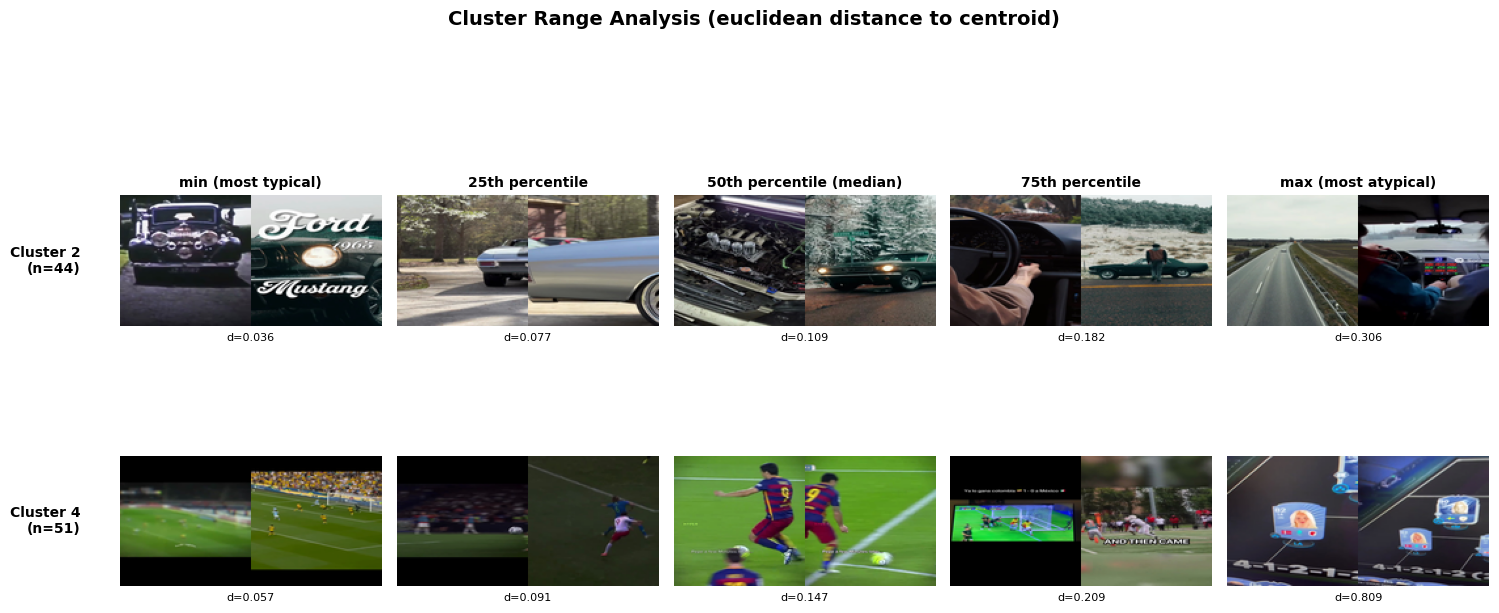

In [18]:
# viewing the clusters that seem like outliers (soccer, and cars)
clusters_of_interest = [2, 4] 

# Using the UMAP embeddings (lower dimensional, what clustering was based on)
fig, range_results = createClusterRangeVisualization(
    cluster_ids=clusters_of_interest,
    embeddings=results['umap_embeddings'],  
    labels=results['labels'],
    metadata=results['metadata'],
    metric='euclidean',  # 'euclidean' for UMAP space
    n_per_quantile=2,
    output_path='output/cluster_range_analysis.png'
)

plt.show()

# Idea Trois:
- An interactive HTML viz
- Defined in seperate py script for cleanliness

In [19]:
# import html viz preparation scripts (defined in seperate py file for cleanliness)
from utils.prepare_interactive_viz import prepareInteractiveVisualizationWithAllImages

## Refine interactive viz
- Now that I've made an interactive visualization, I will just show ALL clusters

In [20]:
def createFilteredVisualization(results_dict, output_path, exclude_clusters=None,
                                 include_clusters=None, n_columns=3, max_clusters_display=None):
    """
    create a visualization with specific clusters included or excluded.
    """
    # get all cluster ids
    all_cluster_ids = sorted(results_dict['cluster_representatives'].keys())
    
    # filter clusters
    if include_clusters is not None:
        filtered_ids = [cid for cid in include_clusters if cid in all_cluster_ids]
    elif exclude_clusters is not None:
        filtered_ids = [cid for cid in all_cluster_ids if cid not in exclude_clusters]
    else:
        filtered_ids = all_cluster_ids
    
    # apply max_clusters_display (by size)
    if max_clusters_display and len(filtered_ids) > max_clusters_display:
        labels = results_dict['labels']
        cluster_sizes = {cid: np.sum(labels == cid) for cid in filtered_ids}
        sorted_by_size = sorted(cluster_sizes.items(), key=lambda x: x[1], reverse=True)
        filtered_ids = [cid for cid, _ in sorted_by_size[:max_clusters_display]]
    
    # create filtered representatives dict
    filtered_representatives = {
        cid: results_dict['cluster_representatives'][cid] 
        for cid in filtered_ids
    }
    
    print(f"creating visualization with {len(filtered_ids)} clusters")
    
    # generate visualization
    createVisualizationGrid(
        cluster_representatives=filtered_representatives,
        metadata=results_dict['metadata'],
        cluster_keywords=results_dict['cluster_keywords'],
        cluster_genres=results_dict['cluster_genres'],
        cluster_comments=results_dict['cluster_comments'],
        labels=results_dict['labels'],
        output_path=output_path,
        n_columns=n_columns,
        max_clusters_display=None
    )

In [21]:
# using all clusters for viz for website
createFilteredVisualization(
    results_dict=results,
    output_path='output/viz_all.png',
    exclude_clusters=None,
    include_clusters=None,
    n_columns=10,
    max_clusters_display=None
)

creating visualization with 189 clusters
visualization saved to: output/viz_all.png


In [22]:
prepareInteractiveVisualizationWithAllImages(
    results_dict=results,
    audio_dir='audio_extracted',
    output_dir='interactive_viz',
    composite_image_path='output/viz_all.png',
    max_clusters=None,
    n_range_images=2
)

processing 189 clusters...


processing clusters: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 189/189 [00:37<00:00,  5.00it/s]


data prepared in: interactive_viz


PosixPath('interactive_viz')

# Analysis Code
- This is where I render specific clusters of interest, and their ranges, for analysis in the paper
- Reminder to self: To render clusters of interest:
```
# viewing the clusters that seem like outliers (soccer, and carsO
clusters_of_interest = [2, 4] 

# Using the UMAP embeddings (lower dimensional, what clustering was based on)
fig, range_results = createClusterRangeVisualization(
    cluster_ids=clusters_of_interest,
    embeddings=results['umap_embeddings'],  
    labels=results['labels'],
    metadata=results['metadata'],
    metric='euclidean',  # 'euclidean' for UMAP space, 'cosine' for CLIP space
    n_per_quantile=2,
    output_path='final_cluster/cluster_range_analysis.png'
)

plt.show()
```

In [23]:
# functions to render specific cluster composites

def renderClusterCard(cluster_id, results_dict, output_path=None,
                      composite_size=300, figsize=(6, 8), title_fontsize=11):
    """
    render a single cluster's composite image with all labels.
    """
    metadata = results_dict['metadata']
    cluster_representatives = results_dict['cluster_representatives']
    cluster_keywords = results_dict['cluster_keywords']
    cluster_comments = results_dict['cluster_comments']
    cluster_genres = results_dict['cluster_genres']
    
    if cluster_id not in cluster_representatives:
        print(f"cluster {cluster_id} not found")
        return None
    
    # get representative images
    rep_indices = cluster_representatives[cluster_id]
    image_paths = [metadata[i]['image_path'] for i in rep_indices]
    
    # create composite image
    composite = createClusterComposite(image_paths, grid_size=(3, 3), image_size=composite_size)
    
    # get text labels
    keywords = cluster_keywords.get(cluster_id, [])
    keywords_str = ', '.join(keywords[:5]) if keywords else 'no keywords'
    comments_str = cluster_comments.get(cluster_id, 'no comments')
    genre_str = cluster_genres.get(cluster_id, 'unknown')
    
    # truncate if needed
    max_len = 60
    if len(keywords_str) > max_len:
        keywords_str = keywords_str[:max_len-3] + '...'
    if len(comments_str) > max_len:
        comments_str = comments_str[:max_len-3] + '...'
    if len(genre_str) > max_len:
        genre_str = genre_str[:max_len-3] + '...'
    
    # create figure
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(composite)
    ax.axis('off')
    
    title = (f"sign: {cluster_id}\n"
            f"text: {keywords_str}\n"
            f"interpretant: {comments_str}\n"
            f"genre: {genre_str}")
    
    ax.set_title(title, fontsize=title_fontsize, pad=15,
                ha='center', va='top',
                multialignment='left',
                linespacing=1.3,
                fontfamily='monospace')
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight',
                   facecolor='white', pad_inches=0.2)
        print(f"saved: {output_path}")
    
    return fig


def renderClusterCards(cluster_ids, results_dict, output_path=None,
                       n_columns=3, composite_size=200, title_fontsize=9,
                       max_text_length=50):
    """
    render multiple cluster cards in a grid.
    """
    metadata = results_dict['metadata']
    cluster_representatives = results_dict['cluster_representatives']
    cluster_keywords = results_dict['cluster_keywords']
    cluster_comments = results_dict['cluster_comments']
    cluster_genres = results_dict['cluster_genres']
    
    # filter to valid clusters
    valid_ids = [cid for cid in cluster_ids if cid in cluster_representatives]
    if not valid_ids:
        print("no valid cluster ids found")
        return None
    
    n_clusters = len(valid_ids)
    n_rows = (n_clusters + n_columns - 1) // n_columns
    
    fig_width = n_columns * 5
    fig_height = n_rows * 6
    
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = gridspec.GridSpec(n_rows, n_columns, figure=fig,
                          hspace=0.5, wspace=0.3,
                          top=0.95, bottom=0.05, left=0.05, right=0.95)
    
    def truncate(text, max_len):
        if len(text) > max_len:
            return text[:max_len-3] + '...'
        return text
    
    for idx, cluster_id in enumerate(valid_ids):
        row = idx // n_columns
        col = idx % n_columns
        
        ax = fig.add_subplot(gs[row, col])
        
        # get representative images and create composite
        rep_indices = cluster_representatives[cluster_id]
        image_paths = [metadata[i]['image_path'] for i in rep_indices]
        composite = createClusterComposite(image_paths, grid_size=(3, 3),
                                          image_size=composite_size)
        
        ax.imshow(composite)
        ax.axis('off')
        
        # get and format labels
        keywords = cluster_keywords.get(cluster_id, [])
        keywords_str = ', '.join(keywords[:5]) if keywords else 'no keywords'
        comments_str = cluster_comments.get(cluster_id, 'no comments')
        genre_str = cluster_genres.get(cluster_id, 'unknown')
        
        title = (f"sign: {cluster_id}\n"
                f"text: {truncate(keywords_str, max_text_length)}\n"
                f"interpretant: {truncate(comments_str, max_text_length)}\n"
                f"genre: {truncate(genre_str, max_text_length)}")
        
        ax.set_title(title, fontsize=title_fontsize, pad=10,
                    ha='center', va='top',
                    multialignment='left',
                    linespacing=1.2)
    
    # hide empty subplots
    for idx in range(n_clusters, n_rows * n_columns):
        row = idx // n_columns
        col = idx % n_columns
        ax = fig.add_subplot(gs[row, col])
        ax.axis('off')
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight',
                   facecolor='white', pad_inches=0.2)
        print(f"saved: {output_path}")
    
    return fig


def extractClusterFromViz(cluster_id, results_dict, source_viz_path=None, output_path=None):
    """
    quick extraction - renders the cluster card without needing the source viz.
    alias for renderClusterCard with sensible defaults.
    """
    return renderClusterCard(
        cluster_id=cluster_id,
        results_dict=results_dict,
        output_path=output_path or f'clustering_output_2/cluster_{cluster_id}_card.png'
    )

saved: output/specific_clusters/cluster_98.png


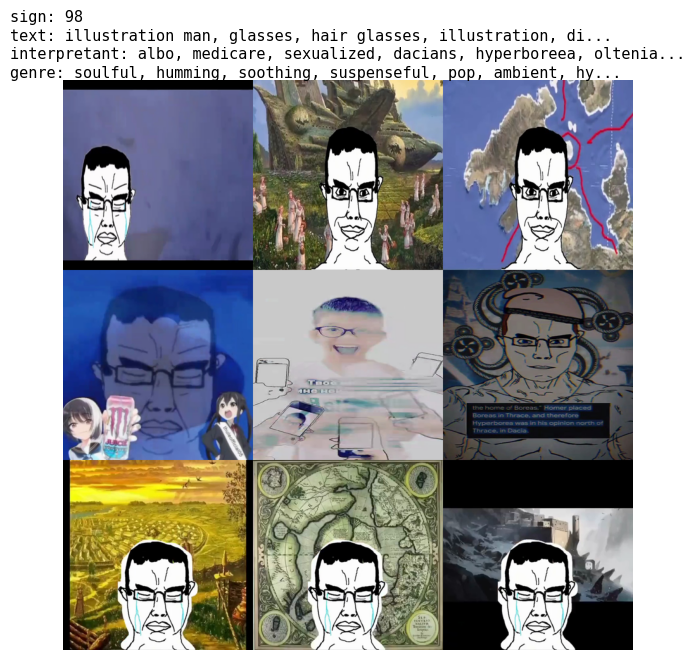

saved: output/specific_clusters/cluster_177.png


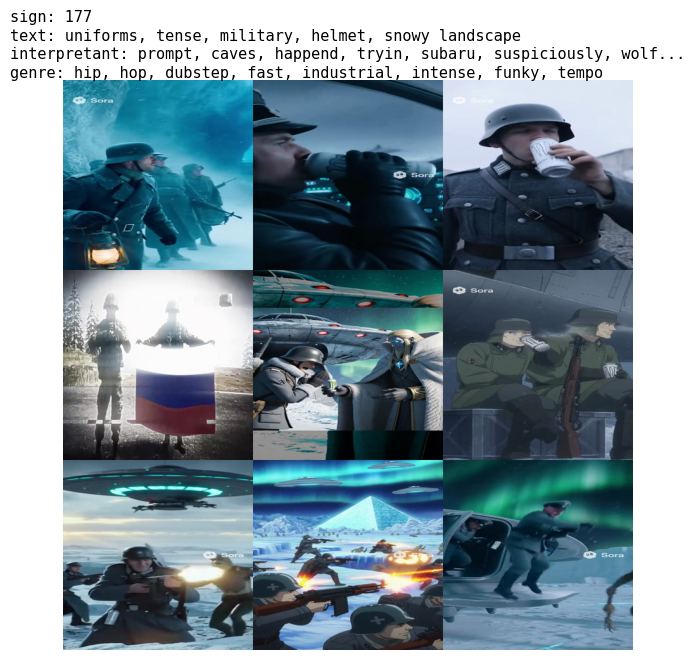

saved: output/specific_clusters/cluster_10.png


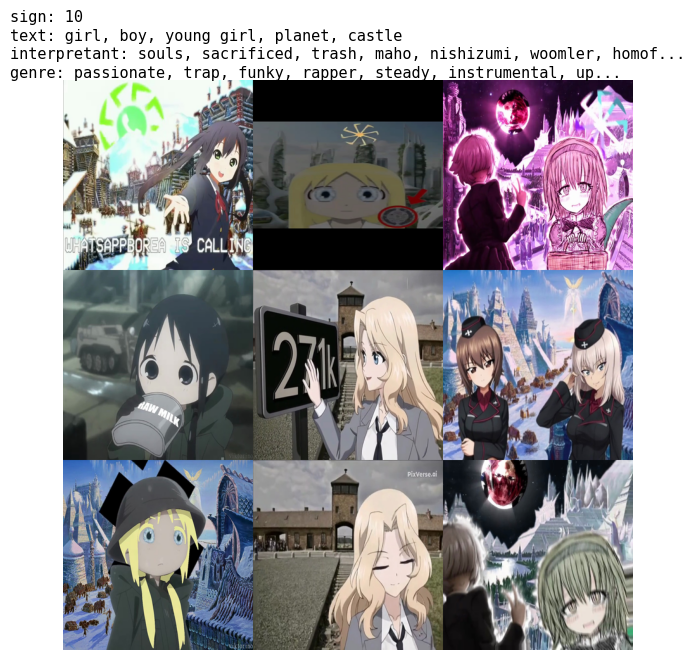

saved: output/specific_clusters/cluster_80.png


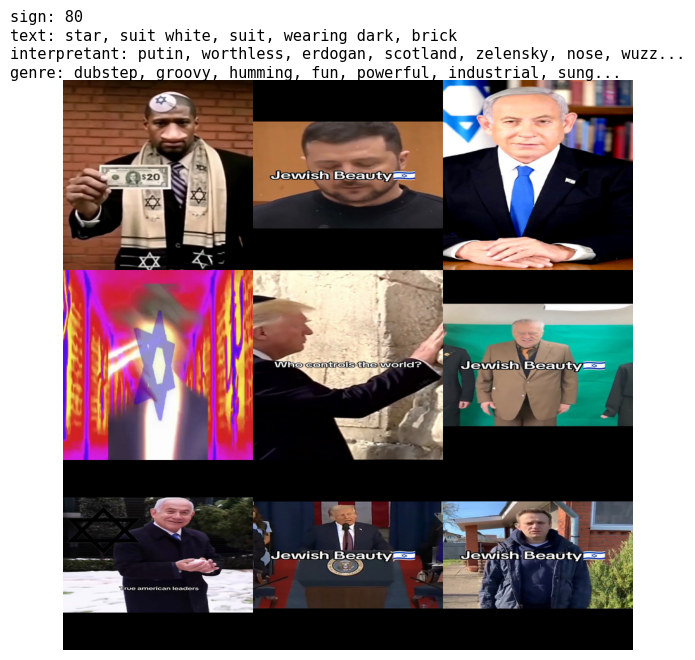

saved: output/specific_clusters/cluster_100.png


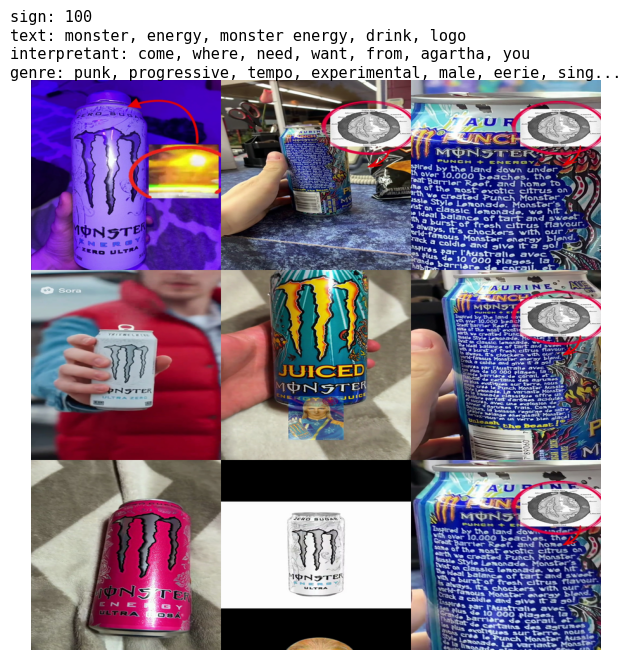

saved: output/specific_clusters/cluster_165.png


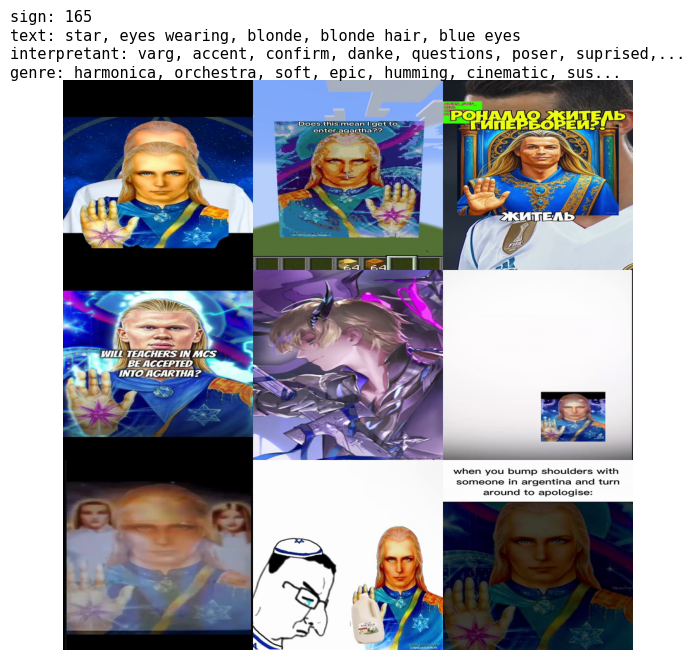

saved: output/specific_clusters/cluster_156.png


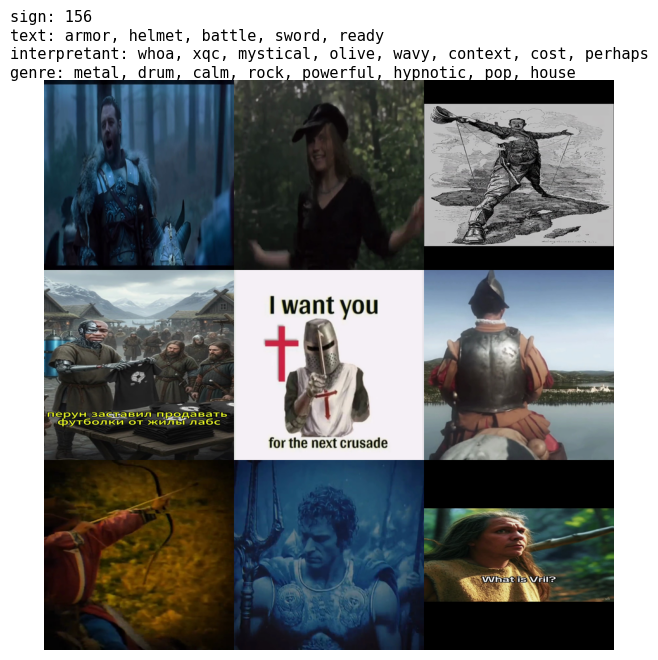

saved: output/specific_clusters/cluster_68.png


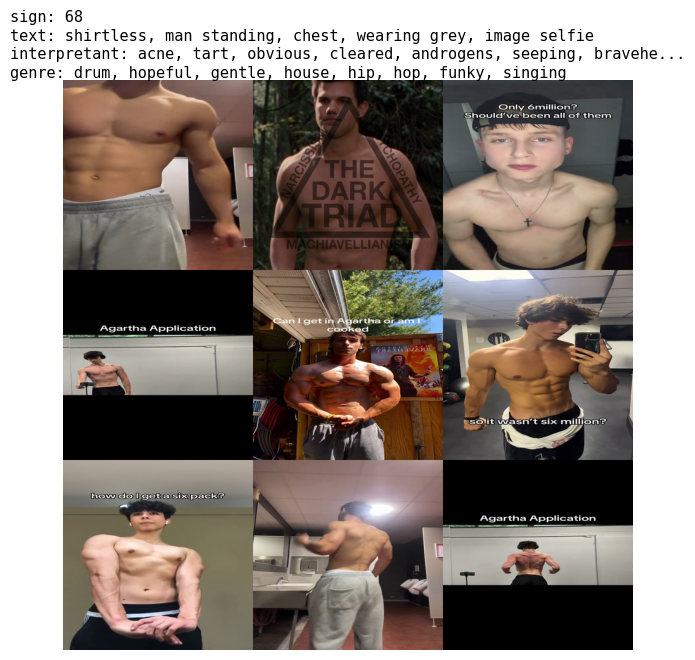

saved: output/specific_clusters/cluster_21.png


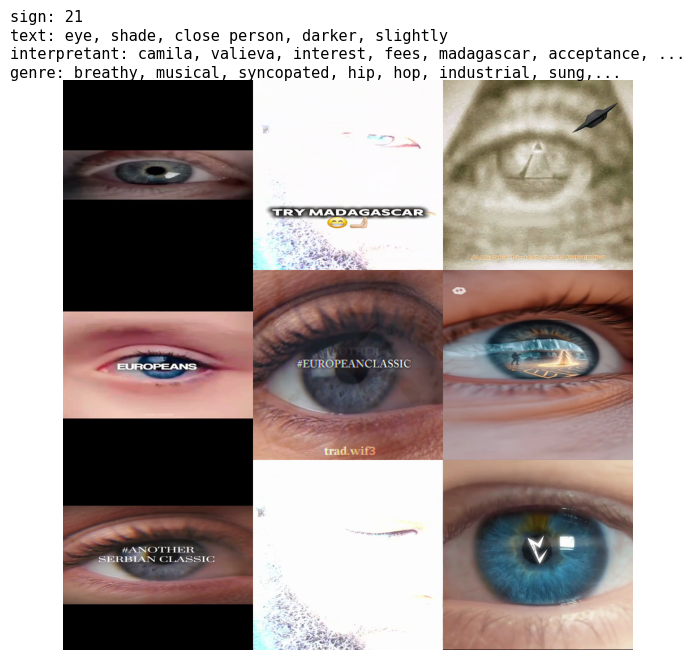

saved: output/specific_clusters/cluster_114.png


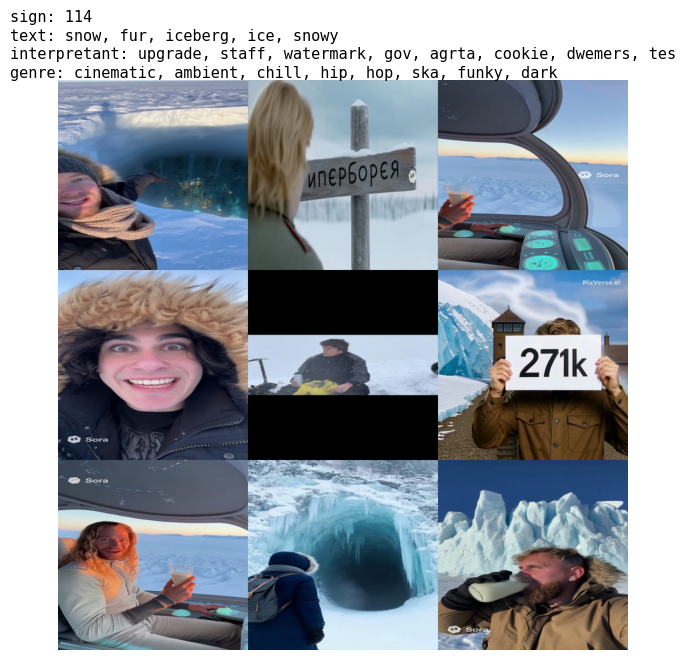

saved: output/specific_clusters/cluster_175.png


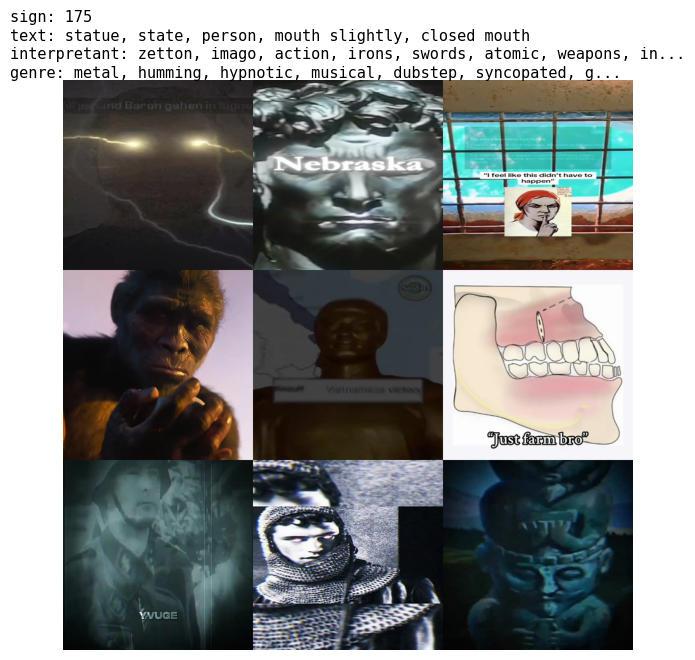

saved: output/specific_clusters/cluster_158.png


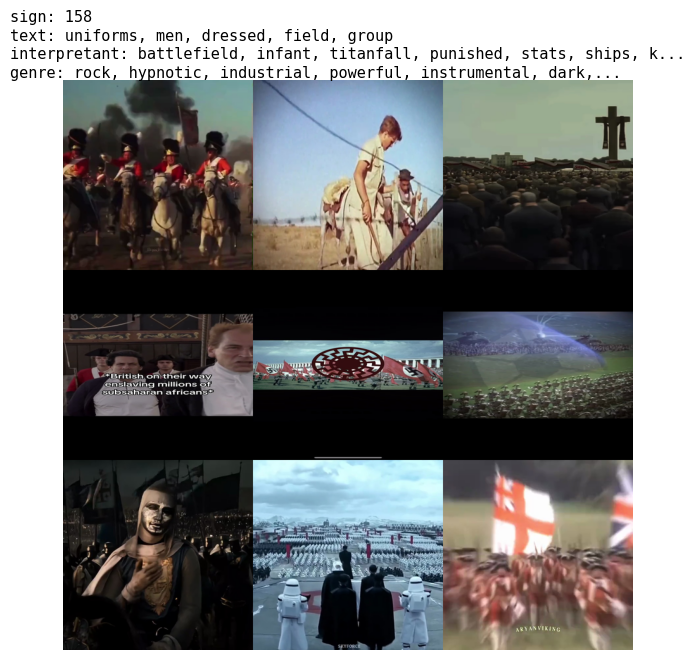

saved: output/specific_clusters/cluster_90.png


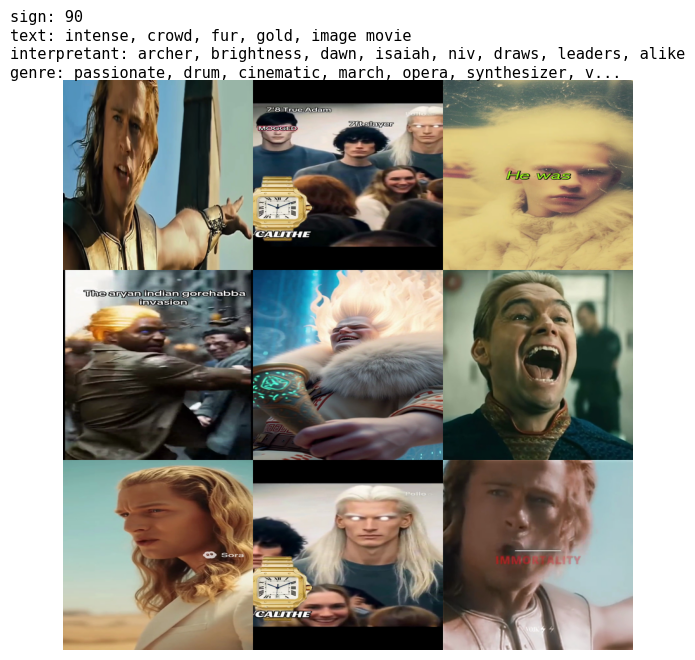

In [27]:
# make multiple seperate composites
selected_list = [98, 177, 10, 80, 100, 165, 156, 68, 21, 114, 175, 158, 90]

for sign in selected_list:
    fig = renderClusterCard(
        cluster_id=sign,
        results_dict=results,
        output_path=f'output/specific_clusters/cluster_{sign}.png'
    )
    plt.show()

In [ ]:
# Rendering multiple seperately, two together
fig = renderClusterCards(
    cluster_ids=[54, 63],
    results_dict=results,
    output_path='output/specific_clusters/women_clusters.png',
    n_columns=2
)
plt.show()